In [1]:
import numpy as np
from numpy import pi, sqrt
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
from scipy.stats import norm
import emcee
import corner
import seaborn as sns
import pandas as pd
import multiprocess as mp
import os
import saxs_helpers as sm

# Load FoXS-simulated SAXS from atomic model (pre-interpolated to match the data).
# Ensure that this file is located in the same directory as this notebook along with saxs_models.py
FoXS_BMCH = "5djb_FoXS.dat"
q, Iq_h, err_Iq_h = sm.loadDatFile(FoXS_BMCH)

### Define Bayesian likelihood and posterior

The cell below defines the log(likelihood) and log(posterior) functions that are used in each MCMC analysis.

For each set of experiments, we impose lower and upper bounds on the parameter values in order to constrain the large parameter space to a smaller region for the random walkers to explore, as the algorithm in its current state is relatively inefficient. Once the bounds are defined, we can then define the priors.

In [3]:
def log_likelihood(theta, q, I, sigma):
    (radius, sigma_radius, length, d_spacing, sigma_d_spacing, Nlayers, Caille_parameter, radius_vesicle, sigma_radius_vesicle, thickness, delta_rho, scale_cyl, scale_lam, scale_vesicle, scale_h, background) = theta
    try:
        model = sm.combined_model(q, radius, sigma_radius, length, d_spacing, sigma_d_spacing, Nlayers, Caille_parameter, radius_vesicle, sigma_radius_vesicle, thickness, delta_rho, scale_cyl, scale_lam, scale_vesicle, scale_h, background, n_poly=50, n_int=50)
    except Exception:
        return -np.inf
    if not np.all(np.isfinite(model)):
        return -np.inf
    chi2 = np.sum(((I - model) / sigma) ** 2)
    return -0.5 * chi2

def log_probability(theta, q, I, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, q, I, sigma)

In [4]:
# Parameter labels
labels_cyl = ["radius_cyl", "sigma_radius_cyl", "length"]
labels_lam = ["d_spacing", "sigma_d_spacing", "Nlayers", "Caille_parameter"]
labels_ves = ["radius_ves", "sigma_radius_ves"]
labels_material = ["thickness", "delta_rho"]
labels_scb = ["scale_cyl", "scale_lam", "scale_ves", "scale_h", "background"]

labels = labels_cyl + labels_lam + labels_ves + labels_material + labels_scb

## BMC-H samples assembled via dilution in 100 mM urea and in various salt concentrations

In [6]:
# Specify data file locations and file names
data_dir = 'SAXS Data/Dil_Salt/'
data_files = [
    'H_0N_100U.dat',
    'H_10N_100U.dat',
    'H_20N_100U.dat',
    'H_50N_100U.dat',
    'H_100N_100U.dat',
    'H_200N_100U.dat'
]

# Dictionary of parameter value constraints (lower, upper)
bounds_dict = { "radius_cyl":       (350, 650),
                "sigma_radius_cyl": (40, 200),
                "length":           (1e4, 1e7),
                "d_spacing":        (90, 150),
                "sigma_d_spacing":  (0, 50),
                "Nlayers":          (1, 50),
                "Caille_parameter": (0, 0.8),
                "radius_ves":       (85, 250),
                "sigma_radius_ves": (0, 100),
                "thickness":        (20, 90),
                "delta_rho":        (1e-4, 1e-3),
                "scale_cyl":        (0, 1e10),
                "scale_lam":        (0, 1e10),
                "scale_ves":        (0, 1e3),
                "scale_h":          (0, 1e10),
                "background":       (0, 1e10)}

lower_bounds = np.array([bounds_dict[label][0] for label in labels])
upper_bounds = np.array([bounds_dict[label][1] for label in labels])

# Define the uniform prior using the lower and upper bounds
def log_prior(theta):
    if not np.all((theta >= lower_bounds) & (theta <= upper_bounds)):
        return -np.inf
    return 0.0

In [7]:
# Initial guesses (obtained using least square fitting)
initial_guesses = np.array([
    [3.84109546e+02, 4.11502389e+01, 8.66788996e+04, 1.46327023e+02,
     5.59617835e+00, 5.38076766e+00, 5.19141247e-02, 9.62087431e+01,
     3.88920620e+00, 3.10147037e+01, 3.60826908e-04, 5.39907351e+00,
     1.20687494e+02, 6.30225831e-04, 7.24978777e-08, 5.75905583e-03],
    [4.15750308e+02, 4.62881435e+01, 9.41127294e+04, 1.36238560e+02,
     1.09976005e+01, 9.35129201e+00, 3.28127684e-03, 9.44197862e+01,
     1.90788643e+00, 3.25600623e+01, 4.74926197e-04, 2.75944493e+01,
     1.19988394e+02, 4.23246533e-01, 6.26571413e-08, 4.83704927e-02],
    [4.13709097e+02, 4.23422422e+01, 8.98162049e+04, 1.27277913e+02,
     9.57845880e+00, 9.58136595e+00, 1.63302002e-02, 9.64257379e+01,
     1.81747897e+00, 2.99696965e+01, 2.32270010e-04, 3.90799545e+01,
     3.64092485e+02, 1.14911030e+01, 5.07714954e-08, 2.15808555e-02],
    [4.11798596e+02, 4.83350417e+01, 9.45658616e+04, 1.10224660e+02,
     6.49629784e+00, 1.05846586e+01, 9.81921102e-02, 9.94502146e+01,
     4.83076846e-01, 2.69101909e+01, 5.02153920e-04, 1.15645262e+01,
     8.91719086e+01, 1.73864419e+02, 3.79222989e-08, 1.67027885e-02],
    [4.02409519e+02, 4.98792353e+01, 4.06885939e+05, 9.39241582e+01,
     3.69727724e+00, 1.46268589e+01, 2.89609143e-01, 9.63690216e+01,
     7.89373402e-02, 4.44828610e+01, 4.25208581e-04, 9.96496480e-11,
     5.52543452e+01, 3.28060957e+01, 4.20358141e-08, 5.58093271e-02],
    [3.80000333e+02, 4.99988786e+01, 7.14585039e+04, 9.00001645e+01,
     2.08310811e+01, 1.46237939e+01, 4.70862474e-01, 8.67675304e+01,
     1.72453585e-01, 4.49990866e+01, 7.83259770e-04, 3.94344560e-01,
     7.87400995e+00, 4.93392609e+02, 1.25487999e-08, 9.84284518e-02]
])

cylinder params: r = 384, σ_r = 41.2, L = 8.67e+04
lamella params: d = 146, σ_d = 5.6, N = 5.38, η (Caille) = 0.0519
vesicle params: r = 96.2, σ_r = 3.89
material params: t = 31, Δρ = 0.000361
scales: cyl = 5.4, lam = 121, ves = 0.00063, h = 7.25e-08
background: bg = 0.00576


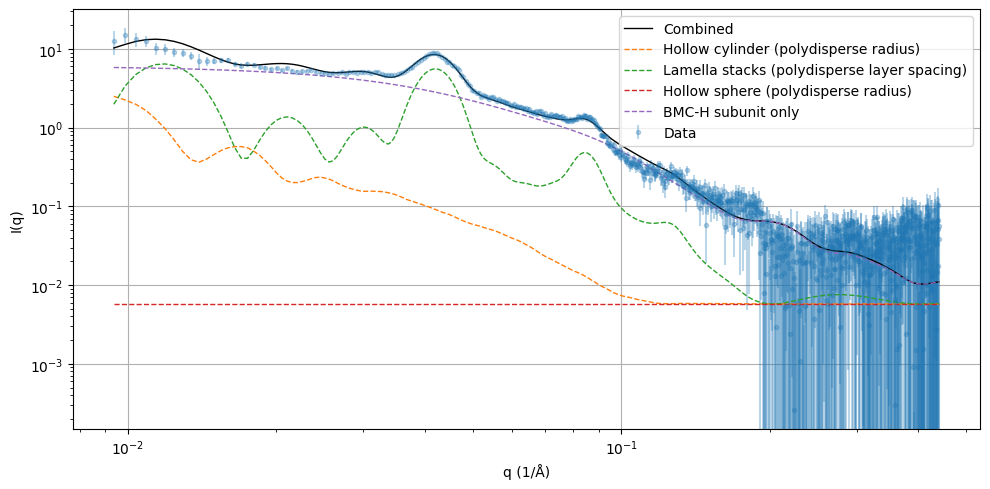

In [8]:
# Inspection of initial guesses for individual curves
file_num = 0
file = data_files[file_num]
q, Iq, err_Iq = sm.loadDatFile(data_dir + file) # Load data
sm.showIndividualCurves(q, Iq, err_Iq, initial_guesses[file_num,:], labels) # Show data, model, and individual contributions

### Run MCMC for dilution salt series

In [10]:
# This cell loops over each data file, running MCMC in multiple rounds for each file.
# This allows the user to evaluate the progress of the MCMC runs after each round.

# 'steps_per_round' is the number of steps the random walkers take per round.
# 'n_rounds' is the total number of rounds run per file.
# The total number of steps the random walkers take is therefore steps_per_round * n_rounds.

steps_per_round = 8000
n_rounds = 1

# Temporary burn-in and thin for visualization
burnin=1
thin=1

for round_idx in range(n_rounds):
    print(f"\n Round {round_idx+1}/{n_rounds}\n")
    
    for file_num in range(0, len(data_files)):
        file = data_files[file_num]
        q, Iq, err_Iq = sm.loadDatFile(data_dir + file)
        initial_guess = initial_guesses[file_num, :]
        ndim = len(initial_guess)
        nwalkers = ndim * 5

        file_only = file.split('/')[-1].split('.')[0]
        print(file_only)
        filename = f"Backend files/backend_{file_only}.h5"

        # If file does not exist, create and initialize backend
        if not os.path.exists(filename):
            backend = emcee.backends.HDFBackend(filename)
            backend.reset(nwalkers, ndim)

            # Initialize walkers
            pos = np.zeros((nwalkers, ndim))
            spread = 1e-4
            max_attempts = 10000
            for i in range(nwalkers):
                attempt = 0
                while attempt < max_attempts:
                    trial = initial_guess + spread * np.abs(initial_guess) * np.random.randn(ndim)
                    trial = np.clip(trial, lower_bounds, upper_bounds)
                    if np.isfinite(log_prior(trial)):
                        pos[i] = trial
                        break
                    attempt += 1
                else:
                    raise RuntimeError(f"Walker {i} failed to initialize for file {file}")
        else:
            backend = emcee.backends.HDFBackend(filename)
            pos = None  # continue from where it left off

        # Run sampler
        with mp.Pool(processes=8) as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, log_probability, args=(q, Iq, err_Iq),
                pool=pool, backend=backend
            )
            sampler.run_mcmc(pos, steps_per_round, progress=True)

        # Uncomment to evaluate fits
        #samples, log_prob, theta_map = sm.getSamplesLogProbThetaMap(sampler, burnin=burnin, thin=thin)
        #sm.showIndividualCurves(q, Iq, err_Iq, theta_map, labels)


 Round 1/1

H_0N_100U


100%|████████████████████████████████████████████████████████████████| 8000/8000 [1:43:15<00:00,  1.29it/s]

H_10N_100U



100%|████████████████████████████████████████████████████████████████| 8000/8000 [1:56:10<00:00,  1.15it/s]

H_20N_100U


...


100%|████████████████████████████████████████████████████████████████| 8000/8000 [2:00:13<00:00,  1.11it/s]

H_100N_100U



100%|████████████████████████████████████████████████████████████████| 8000/8000 [2:01:45<00:00,  1.10it/s]

H_200N_100U



100%|████████████████████████████████████████████████████████████████| 8000/8000 [1:49:50<00:00,  1.21it/s]


## BMC-H samples assembled via buffer exchange in 0 mM urea and in various salt concentrations

In [12]:
# Specify data file locations and file names
data_dir = 'SAXS Data/BE_Salt/'
data_files = [
    'BE_0N.dat',
    'BE_10N.dat',
    'BE_20N.dat',
    'BE_50N.dat'
]

# Dictionary of parameter value constraints (lower, upper)
bounds_dict = { "radius_cyl":       (350, 500),
                "sigma_radius_cyl": (10, 100),
                "length":           (1e4, 1e7),
                "d_spacing":        (90, 150),
                "sigma_d_spacing":  (0, 50),
                "Nlayers":          (1, 50),
                "Caille_parameter": (0, 0.8),
                "radius_ves":       (85, 250),
                "sigma_radius_ves": (0, 100),
                "thickness":        (20, 90),
                "delta_rho":        (1e-4, 1e-3),
                "scale_cyl":        (0, 1e10),
                "scale_lam":        (0, 1e3),
                "scale_ves":        (0, 1e10),
                "scale_h":          (0, 1e10),
                "background":       (0, 1e10)}

lower_bounds = np.array([bounds_dict[label][0] for label in labels])
upper_bounds = np.array([bounds_dict[label][1] for label in labels])

# Define the uniform prior using the lower and upper bounds
def log_prior(theta):
    if not np.all((theta >= lower_bounds) & (theta <= upper_bounds)):
        return -np.inf
    return 0.0

In [13]:
# Initial guesses (obtained using least square fitting)
initial_guesses = np.array([
    [4.28797117e+02, 4.35042255e+01, 4.97795055e+04, 1.41829934e+02,
     4.88054112e+01, 1.75961791e+00, 7.89407534e-01, 8.58223993e+01,
     9.55431336e+00, 3.26040598e+01, 9.87056914e-04, 2.69024367e+01,
     4.88849312e-09, 1.60337970e+08, 6.67793863e-08, 3.99030335e-01],
    [4.24438075e+02, 4.91438183e+01, 5.75535214e+04, 9.56498166e+01,
     4.42853867e+01, 1.23504286e+00, 4.02825839e-02, 9.00489225e+01,
     9.72654016e+00, 3.88791298e+01, 9.83726813e-04, 4.51781309e+01,
     2.06691564e+00, 1.26685538e+08, 1.31788547e-07, 3.11420504e-01],
    [4.21577912e+02, 4.02434124e+01, 4.48378122e+04, 1.50000000e+02,
     2.43079535e+01, 4.04360193e+01, 7.26080864e-01, 8.51464831e+01,
     1.14246047e+01, 2.91703573e+01, 5.71753087e-04, 6.32723075e+01,
     1.76546405e+02, 2.02654636e+08, 4.13995172e-33, 3.68858811e-01],
    [4.25492493e+02, 5.64038559e+01, 5.09262394e+04, 1.23051976e+02,
     1.13652873e+01, 4.42083010e+01, 5.07946132e-01, 1.20157777e+02,
     6.21084470e+00, 3.08603034e+01, 4.34689209e-04, 2.25014313e+02,
     2.47484266e+02, 2.02656125e+08, 1.08232518e-16, 3.78082946e-01]
])

cylinder params: r = 429, σ_r = 43.5, L = 4.98e+04
lamella params: d = 142, σ_d = 48.8, N = 1.76, η (Caille) = 0.789
vesicle params: r = 85.8, σ_r = 9.55
material params: t = 32.6, Δρ = 0.000987
scales: cyl = 26.9, lam = 4.89e-09, ves = 1.6e+08, h = 6.68e-08
background: bg = 0.399


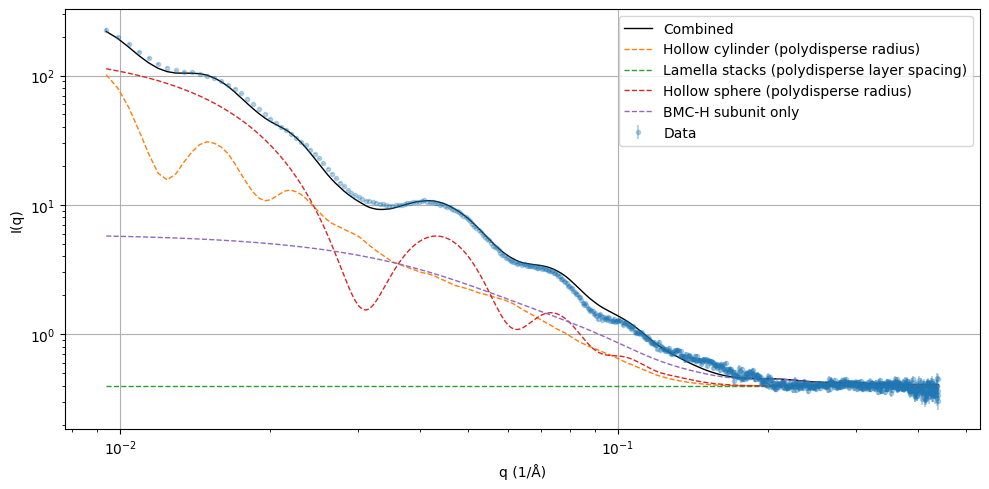

In [14]:
# Inspection of initial guesses for individual curves
file_num = 0
file = data_files[file_num]
q, Iq, err_Iq = sm.loadDatFile(data_dir + file) # Load data
sm.showIndividualCurves(q, Iq, err_Iq, initial_guesses[file_num,:], labels) # Show data, model, and individual contributions

### Run MCMC for buffer exchange salt series

In [16]:
# This cell loops over each data file, running MCMC in multiple rounds for each file.
# This allows the user to evaluate the progress of the MCMC runs after each round.

# 'steps_per_round' is the number of steps the random walkers take per round.
# 'n_rounds' is the total number of rounds run per file.
# The total number of steps the random walkers take is therefore steps_per_round * n_rounds.

steps_per_round = 8000
n_rounds = 1

# Temporary burn-in and thin for visualization
burnin=1
thin=1

for round_idx in range(n_rounds):
    print(f"\n Round {round_idx+1}/{n_rounds}\n")
    
    for file_num in range(0, len(data_files)):
            
        file = data_files[file_num]
        q, Iq, err_Iq = sm.loadDatFile(data_dir + file)
        initial_guess = initial_guesses[file_num, :]
        ndim = len(initial_guess)
        nwalkers = ndim * 5

        file_only = file.split('/')[-1].split('.')[0]
        print(file_only)
        filename = f"Backend files/backend_{file_only}.h5"

        # If file does not exist, create and initialize backend
        if not os.path.exists(filename):
            backend = emcee.backends.HDFBackend(filename)
            backend.reset(nwalkers, ndim)

            # Initialize walkers
            pos = np.zeros((nwalkers, ndim))
            spread = 1e-4
            max_attempts = 10000
            for i in range(nwalkers):
                attempt = 0
                while attempt < max_attempts:
                    trial = initial_guess + spread * np.abs(initial_guess) * np.random.randn(ndim)
                    trial = np.clip(trial, lower_bounds, upper_bounds)
                    if np.isfinite(log_prior(trial)):
                        pos[i] = trial
                        break
                    attempt += 1
                else:
                    raise RuntimeError(f"Walker {i} failed to initialize for file {file}")
        else:
            backend = emcee.backends.HDFBackend(filename)
            pos = None  # continue from where it left off

        # Run sampler
        with mp.Pool(processes=8) as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, log_probability, args=(q, Iq, err_Iq),
                pool=pool, backend=backend
            )
            sampler.run_mcmc(pos, steps_per_round, progress=True)

        # Uncomment to evaluate fits
        #samples, log_prob, theta_map = sm.getSamplesLogProbThetaMap(sampler, burnin=burnin, thin=thin)
        #sm.showIndividualCurves(q, Iq, err_Iq, theta_map, labels)


 Round 1/1

BE_0N


100%|████████████████████████████████████████████████████████████████| 8000/8000 [1:55:04<00:00,  1.16it/s]

BE_10N



100%|████████████████████████████████████████████████████████████████| 8000/8000 [1:49:57<00:00,  1.21it/s]

BE_20N



100%|████████████████████████████████████████████████████████████████| 8000/8000 [2:05:09<00:00,  1.07it/s]

BE_50N



100%|████████████████████████████████████████████████████████████████| 8000/8000 [2:24:05<00:00,  1.08s/it]


## BMC-H samples assembled via buffer exchange in 0 mM NaCl and in various urea concentrations

In [18]:
# Specify data file locations and file names
data_dir = 'SAXS Data/BE_Urea/'
data_files = [
    'BE_0N_0U.dat',
    'BE_0N_50U.dat',
    'BE_0N_100U.dat',
    'BE_0N_200U.dat'
]

# Dictionary of parameter value constraints (lower, upper)
bounds_dict = { "radius_cyl":       (350, 500),
                "sigma_radius_cyl": (10, 100),
                "length":           (1e4, 1e6),
                "d_spacing":        (90, 150),
                "sigma_d_spacing":  (0, 50),
                "Nlayers":          (1, 50),
                "Caille_parameter": (0, 0.8),
                "radius_ves":       (85, 250),
                "sigma_radius_ves": (0, 100),
                "thickness":        (20, 90),
                "delta_rho":        (1e-4, 1e-3),
                "scale_cyl":        (0, 1e10),
                "scale_lam":        (0, 1e3),
                "scale_ves":        (0, 1e10),
                "scale_h":          (0, 1e10),
                "background":       (0, 1e10)}

lower_bounds = np.array([bounds_dict[label][0] for label in labels])
upper_bounds = np.array([bounds_dict[label][1] for label in labels])

# Define the uniform prior using the lower and upper bounds
def log_prior(theta):
    if not np.all((theta >= lower_bounds) & (theta <= upper_bounds)):
        return -np.inf
    return 0.0

In [19]:
# Initial guesses (obtained using least square fitting)
initial_guesses = np.array([
    [4.40735378e+02, 4.90579587e+01, 4.19090261e+04, 9.02998023e+01,
     4.49811585e+01, 4.97550000e+01, 6.01896433e-01, 8.75704728e+01,
     1.06466878e+01, 2.64654836e+01, 9.88598403e-04, 3.81324917e+01,
     2.71110262e+00, 1.71955815e+08, 3.24199801e-08, 3.83670894e-02],
    [4.40735378e+02, 4.90579587e+01, 4.19090261e+04, 9.02998023e+01,
     4.49811584e+01, 4.97550000e+01, 6.01896433e-01, 8.75704729e+01,
     1.06466878e+01, 2.64654836e+01, 9.88453252e-04, 3.81324917e+01,
     2.71110262e+00, 1.71955815e+08, 1.99302366e-08, 3.83670886e-02],
    [4.12344555e+02, 4.76810900e+01, 5.03417020e+04, 1.19452433e+02,
     4.49704855e+01, 1.43945977e+00, 3.50535226e-01, 8.76795631e+01,
     9.99592346e+00, 2.91191534e+01, 9.77887531e-04, 2.97913486e+01,
     1.43256430e+01, 2.67838295e+08, 7.93827764e-09, 6.03318821e-02],
    [4.00919632e+02, 4.91966012e+01, 5.15484079e+04, 9.03229349e+01,
     4.78491841e+01, 2.89652714e+01, 1.80854570e-01, 8.70469946e+01,
     9.82548077e+00, 3.04146251e+01, 9.16014115e-04, 2.57578104e+01,
     2.75484599e+00, 2.69086215e+08, 6.13140211e-08, 5.49610004e-02]
])

cylinder params: r = 441, σ_r = 49.1, L = 4.19e+04
lamella params: d = 90.3, σ_d = 45, N = 49.8, η (Caille) = 0.602
vesicle params: r = 87.6, σ_r = 10.6
material params: t = 26.5, Δρ = 0.000989
scales: cyl = 38.1, lam = 2.71, ves = 1.72e+08, h = 3.24e-08
background: bg = 0.0384


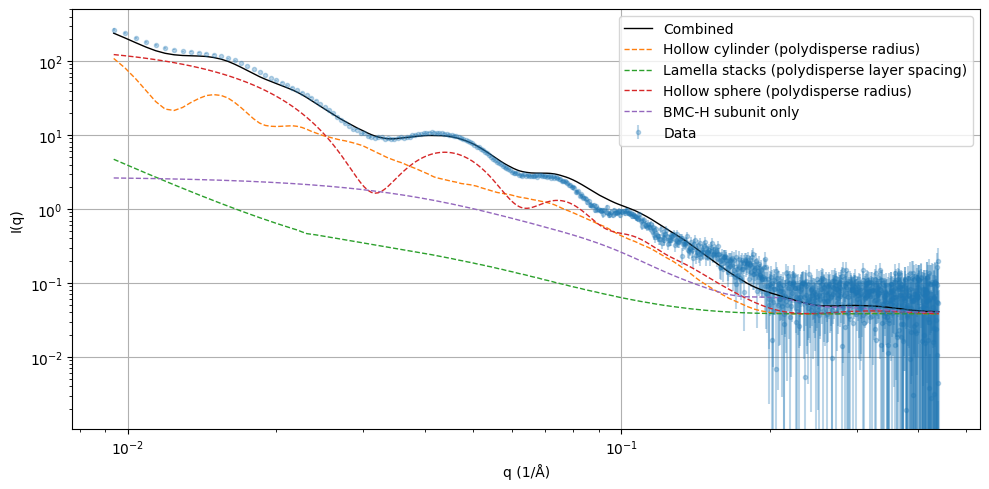

In [20]:
# Inspection of initial guesses for individual curves
file_num = 0
file = data_files[file_num]
q, Iq, err_Iq = sm.loadDatFile(data_dir + file) # Load data
sm.showIndividualCurves(q, Iq, err_Iq, initial_guesses[file_num,:], labels) # Show data, model, and individual contributions

### Run MCMC for buffer exchange urea series

In [22]:
# This cell loops over each data file, running MCMC in multiple rounds for each file.
# This allows the user to evaluate the progress of the MCMC runs after each round.

# 'steps_per_round' is the number of steps the random walkers take per round.
# 'n_rounds' is the total number of rounds run per file.
# The total number of steps the random walkers take is therefore steps_per_round * n_rounds.

steps_per_round = 8000
n_rounds = 1

# Temporary burn-in and thin for visualization
burnin=1
thin=1

for round_idx in range(n_rounds):
    print(f"\n Round {round_idx+1}/{n_rounds}\n")
    
    for file_num in range(0, len(data_files)):
        file = data_files[file_num]
        q, Iq, err_Iq = sm.loadDatFile(data_dir + file)
        initial_guess = initial_guesses[file_num, :]
        ndim = len(initial_guess)
        nwalkers = ndim * 5

        file_only = file.split('/')[-1].split('.')[0]
        print(file_only)
        filename = f"Backend files/backend_{file_only}.h5"

        # If file does not exist, create and initialize backend
        if not os.path.exists(filename):
            backend = emcee.backends.HDFBackend(filename)
            backend.reset(nwalkers, ndim)

            # Initialize walkers
            pos = np.zeros((nwalkers, ndim))
            spread = 1e-4
            max_attempts = 10000
            for i in range(nwalkers):
                attempt = 0
                while attempt < max_attempts:
                    trial = initial_guess + spread * np.abs(initial_guess) * np.random.randn(ndim)
                    trial = np.clip(trial, lower_bounds, upper_bounds)
                    if np.isfinite(log_prior(trial)):
                        pos[i] = trial
                        break
                    attempt += 1
                else:
                    raise RuntimeError(f"Walker {i} failed to initialize for file {file}")
        else:
            backend = emcee.backends.HDFBackend(filename)
            pos = None  # continue from where it left off

        # Run sampler
        with mp.Pool(processes=8) as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, log_probability, args=(q, Iq, err_Iq),
                pool=pool, backend=backend
            )
            sampler.run_mcmc(pos, steps_per_round, progress=True)

        # Uncomment to evaluate fits
        #samples, log_prob, theta_map = sm.getSamplesLogProbThetaMap(sampler, burnin=burnin, thin=thin)
        #sm.showIndividualCurves(q, Iq, err_Iq, theta_map, labels)


 Round 1/1

BE_0N_0U


100%|████████████████████████████████████████████████████████████████| 8000/8000 [1:47:47<00:00,  1.24it/s]

BE_0N_50U



100%|████████████████████████████████████████████████████████████████| 8000/8000 [1:40:27<00:00,  1.33it/s]

BE_0N_100U



100%|████████████████████████████████████████████████████████████████| 8000/8000 [1:50:14<00:00,  1.21it/s]

BE_0N_200U



100%|████████████████████████████████████████████████████████████████| 8000/8000 [2:17:50<00:00,  1.03s/it]
